Projeto: Análise de Avaliações de Clientes com Modelo de Linguagem

Integrantes:
- Mariana Okamoto - 10418069 - 10418069@mackenzista.com.br

Descrição:
Este notebook utiliza um modelo de linguagem baseado em Transformers
para realizar análises textuais em avaliações de clientes, incluindo
classificação de sentimentos, identificação de temas recorrentes
e geração de resumos automáticos.

Histórico de alterações:

- 17/05/2026 – Criação do notebook e importação dos dados
- 17/05/2026 – Implementação da análise textual com modelo de linguagem
- 19/05/2026 – Implementação da classificação de sentimentos e geração de insights

In [27]:
!pip install -U transformers sentencepiece

In [28]:
import pandas as pd
df = pd.read_csv("dataset89coffee_tratado.csv")
df.head()

,Nota,HaQuantoTempo,TipoRefeicao,Preco,Comentario,Comida,Serviço,Ambiente,Barulho,Espera,tamanho_texto
0,4,3 semanas atrás,Café da manhã,R$ 40–60,"fui hoje, domingo, por volta de 09h da manhã j...",5,3,4,Nível moderado de barulho,Não informado,1116
1,5,3 semanas atrás,Outro,R$ 20–40,"a comida é incrível, mas erraram no sabor da m...",5,4,4,"Nível muito alto de barulho, difícil de ouvir",Não informado,388
2,5,2 meses atrás,Outro,R$ 40–60,incrível!!!visitamos a 89 em uma sexta por vol...,5,5,5,Não informado,Não informado,1210
3,2,3 semanas atrás,Outro,R$ 40–60,"vitrine lindaaa, você olha e quer comer tudooo...",2,4,4,Nível moderado de barulho,Sem espera,265
4,5,3 meses atrás,Café da manhã,R$ 80–100,"meu lugar favorito da liba, tem muita fila mas...",5,5,5,Nível moderado de barulho,De 10 a 30 min,815


In [29]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [30]:
amostra = df.head(50).copy()

In [31]:
amostra['sentimento'] = amostra['Comentario'].apply(
    lambda x: classifier(str(x))[0]['label']
)

In [37]:
amostra[['Comentario', 'Nota', 'sentimento']]

,Comentario,Nota,sentimento
0,"fui hoje, domingo, por volta de 09h da manhã j...",4,1 star
1,"a comida é incrível, mas erraram no sabor da m...",5,3 stars
2,incrível!!!visitamos a 89 em uma sexta por vol...,5,5 stars
3,"vitrine lindaaa, você olha e quer comer tudooo...",2,1 star
4,"meu lugar favorito da liba, tem muita fila mas...",5,5 stars
5,"é a segunda vez que visito, esqueci de avaliar...",5,5 stars
6,lovely japanese-style café in liberdade 🇯🇵☕89 ...,5,4 stars
7,"fui em um sábado que era feriado, estava lotad...",5,5 stars
8,pedi o bolo de melão e me surpreendi. é um dos...,4,4 stars
9,"cafeteria diferenciada, comidas feitas com pro...",5,4 stars


In [33]:
amostra['sentimento'].value_counts()

,count
sentimento,
5 stars,18
4 stars,18
3 stars,7
2 stars,4
1 star,3


In [36]:
amostra[
    (amostra['Nota'] >= 4) &
    (amostra['sentimento'].isin(['1 star', '2 stars']))
]

,Nota,HaQuantoTempo,TipoRefeicao,Preco,Comentario,Comida,Serviço,Ambiente,Barulho,Espera,tamanho_texto,sentimento
0,4,3 semanas atrás,Café da manhã,R$ 40–60,"fui hoje, domingo, por volta de 09h da manhã j...",5,3,4,Nível moderado de barulho,Não informado,1116,1 star
21,5,um mês atrás,Café da manhã,R$ 20–40,it was crowded. probably because it's saturday...,5,5,5,Nível moderado de barulho,Sem espera,185,2 stars
45,4,5 meses atrás,Café da manhã,R$ 80–100,muito demorado a fila pra entrar aos domingos ...,5,4,5,Não informado,De 30 a 60 min,199,2 stars
46,5,Editado 3 meses atrás,Não informado,Não informado,"fui em dois dias, no sábado e domingo. os dois...",5,5,5,Não informado,Não informado,745,2 stars


In [88]:
def converter_sentimento(label):
    return int(label[0])

amostra['sentimento_num'] = amostra['sentimento'].apply(converter_sentimento)
amostra['diferenca'] = abs(amostra['Nota'] - amostra['sentimento_num'])
print("Diferença entre a nota e o sentimento detectado: ")
amostra['diferenca'].mean()

Diferença entre a nota e o sentimento detectado: 


np.float64(0.72)

In [54]:
coerencia = (abs(amostra['Nota'] - amostra['sentimento_num']) <= 1).mean() * 100

print(f"Coerência aproximada: {coerencia:.2f}%")

Coerência aproximada: 88.00%


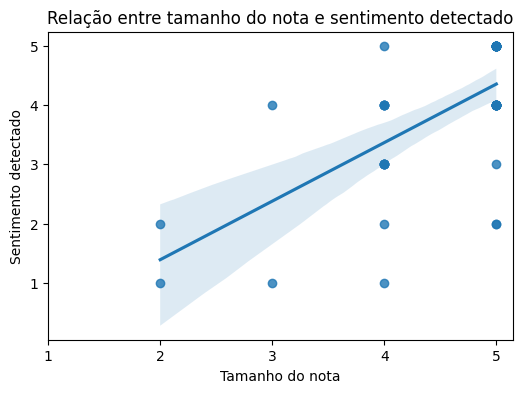

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.regplot(x='Nota', y='sentimento_num', data=amostra)
plt.title("Relação entre tamanho do nota e sentimento detectado")
plt.xlabel("Tamanho do nota")
plt.ylabel("Sentimento detectado")
plt.xticks(np.arange(1, 6, 1))
plt.show()

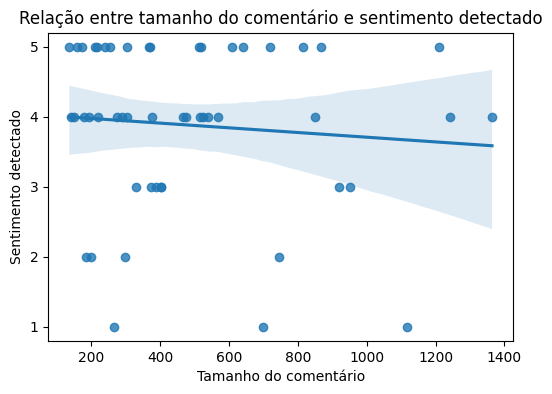

In [85]:
amostra['tamanho_texto'] = amostra['Comentario'].astype(str).apply(len)

plt.figure(figsize=(6,4))
sns.regplot(x='tamanho_texto', y='sentimento_num', data=amostra)
plt.title("Relação entre tamanho do comentário e sentimento detectado")
plt.xlabel("Tamanho do comentário")
plt.ylabel("Sentimento detectado")
plt.yticks(np.arange(1, 6, 1))
plt.show()